# S&P 500 Equity+Options: Portfolio Allocation

This notebook advances the highest-ranked primary-label model configurations
from the equal-weight baseline and tests the point-in-time allocation methods
`setup.yaml` declares. It asks whether portfolio sizing improves validation
performance without changing the prediction model or consulting the holdout.

**Learning objectives**

1. Apply the top-ten, one-checkpoint-per-configuration selection funnel.
2. Compare score weighting, conformal weighting, inverse volatility, risk
   parity, MVO and HRP on the same validation predictions.
3. Measure how the number of selected stocks changes allocation performance.
4. Separate a validation improvement from evidence of out-of-sample efficacy.

**Book reference:** Chapter 17, Sections 17.2-17.8.

**Prerequisites:** `14_backtest` and its registry-backed equal-weight
baselines. Signals form after Friday's close and execute at the next available
open, normally Monday. Every result here is validation data. The
current-constituent universe retains survivorship bias, so results describe
this retrospective roster rather than historical S&P 500 membership or a
prospective index population.

In [1]:
"""S&P 500 Equity+Options: portfolio allocation sweep."""

import sqlite3
import time

import matplotlib.pyplot as plt
import polars as pl

from case_studies.research import (
    OfficialPopulation,
    Study,
    attest_sweep,
    open_study,
    open_sweep_attempt,
    planned_backtests,
    population_supersedes,
    predictions_identity,
    sweep_plan_name,
    upstream_plan_hashes,
)
from case_studies.utils.backtest_loaders import (
    get_backtest_config,
    load_backtest_prices_for,
    warmup_periods_for,
)
from case_studies.utils.backtest_presets import (
    build_backtest_spec,
    traded_universe_declaration,
)
from case_studies.utils.backtest_runner import run_backtest
from case_studies.utils.conformal import ensure_conformal_calibration_identity
from case_studies.utils.notebook_contracts import prediction_members_in_force
from case_studies.utils.registry import (
    backtest_hash_from_parts,
    read_predictions,
    resolve_best_predictions,
)
from case_studies.utils.sweep_config import (
    get_allocators,
    get_checkpoints_per_config,
    get_top_k_values_for,
    get_top_n_predictions,
)
from utils.paths import get_case_study_dir
from utils.style import COLORS, FIGSIZE, add_message_title, show_with_alt

In [2]:
CASE_STUDY_ID = "sp500_equity_option_analytics"
EXECUTION_TIER = "canonical"
WORKSPACE: str = ""
LABEL = ""
MAX_SYMBOLS = 0
SKIP_EXPENSIVE_ALLOC = False
TOP_N_PREDICTIONS = None

### What is asked for, and what it resolves to

The parameters above are the request; the values this notebook runs on are resolved here under
different names, so a resolved value can never overwrite the request that produced it. An
injected parameter wins; otherwise the case study's own declaration does.

In [3]:
# A preview run reads and registers in a smoke chain's own workspace, under `.preview/<case>`,
# and `open_study` is what activates that root. Activation rewrites `ML4T_OUTPUT_DIR` for the
# rest of the process, so it has to happen before the first `get_case_study_dir` rather than
# beside the registry read further down: `CASE_DIR` has to already answer for the workspace.
_preview_study = None
if EXECUTION_TIER == "preview":
    if not WORKSPACE:
        raise ValueError("preview execution requires WORKSPACE")
    _preview_study = open_study(
        CASE_STUDY_ID,
        execution_tier="preview",
        workspace=WORKSPACE,
        entry_point="15_portfolio_management",
    )
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
bt_config = get_backtest_config(CASE_STUDY_ID)
TOP_N = (
    TOP_N_PREDICTIONS
    if TOP_N_PREDICTIONS is not None
    else get_top_n_predictions(CASE_STUDY_ID, "allocation")
)
CHECKPOINTS_PER_CONFIG = get_checkpoints_per_config(CASE_STUDY_ID)
ALLOCATION_LABEL = LABEL or bt_config.primary_label

print(
    f"Case study: {CASE_STUDY_ID}; label: {ALLOCATION_LABEL}; "
    f"top configs: {TOP_N}; checkpoints/config: {CHECKPOINTS_PER_CONFIG}"
)

# `Study.at` is the read-only form: one root, no activation. These notebooks only read the
# populations - their backtests reach the registry by their own paths - and every other way in
# ends in `activate()`, which rewrites `ML4T_OUTPUT_DIR` process-wide. `open_study` with the
# canonical tier routes to `Study.regenerate`, which refuses unless `features`, `labels` and
# `run_log` are symlinks: true in a maintainer worktree, false in every clean clone and CI run.
# `CASE_DIR` is already the directory this notebook resolved, including under a preview, so
# asking it directly answers for the registry the rest of the notebook reads.
_study = (
    _preview_study
    if _preview_study is not None
    else Study.at(CASE_DIR, case_study=CASE_STUDY_ID, entry_point="15_portfolio_management")
)
_members, _population_notes = prediction_members_in_force(_study, CASE_DIR)
for _note in _population_notes:
    print(_note)
CURRENT_MEMBERS = _members

Case study: sp500_equity_option_analytics; label: fwd_ret_5d; top configs: 10; checkpoints/config: 1


143 member(s) were dropped from the candidate pool for covering less than the cross-section their feature panels offered them: 0072f4cecd7e sp500_equity_option_analytics/fwd_ret_10d/validation deep_learning/nlinear: 125119 of 246641 declared (entity, session) pairs (50.7%) across 548 entities; of the 192139 its input panel offered it carries 125119 (65.1%) - 121522 missing; 0113aac277c5 sp500_equity_option_analytics/fwd_ret_risk_adj_5d/validation deep_learning/lstm_h64: 126458 of 248460 declared (entity, session) pairs (50.9%) across 549 entities; of the 194748 its input panel offered it carries 126458 (64.9%) - 122002 missing; 08446871beb5 sp500_equity_option_analytics/fwd_ret_5d/validation deep_learning/lstm_h64: 126478 of 249373 declared (entity, session) pairs (50.7%) across 550 entities; of the 194813 its input panel offered it carries 126478 (64.9%) - 122895 missing; 0932aea6185b sp500_equity_option_analytics/fwd_ret_5d/validation deep_learning/nlinear: 126478 of 249373 declared 

## 1. Advance the leading baselines

Selection uses validation Sharpe and counts distinct `(family, config_name)`
pairs. Each configuration enters through its best full-coverage checkpoint,
so a long checkpoint grid cannot crowd other model families out of the
allocation round.

The baseline sweep this ranks is required first. Its plan says which backtests
the current grid contains, and its attestation says the run that filled them
finished; without both, the leading configurations here are whatever the
registry happens to hold, which is how three of ten configurations advanced on
an unfinished baseline once already.

In [4]:
UPSTREAM_PLANS = upstream_plan_hashes(
    _study,
    case_study=CASE_STUDY_ID,
    label=ALLOCATION_LABEL,
    stage="allocation",
    prediction_hashes=CURRENT_MEMBERS,
)
BASELINE_GRID = planned_backtests(
    _study,
    case_study=CASE_STUDY_ID,
    label=ALLOCATION_LABEL,
    stage="signal",
    prediction_hashes=CURRENT_MEMBERS,
)

In [5]:
top_preds = resolve_best_predictions(
    CASE_STUDY_ID,
    ALLOCATION_LABEL,
    split="validation",
    stage="signal",
    top_n=TOP_N,
    checkpoints_per_config=CHECKPOINTS_PER_CONFIG,
    prediction_hashes=CURRENT_MEMBERS,
    backtest_hashes=BASELINE_GRID,
)
if len(top_preds) != TOP_N:
    raise RuntimeError(f"Expected {TOP_N} advancing configurations, found {len(top_preds)}")

selected_hashes = top_preds["prediction_hash"].to_list()
top_preds.select("source", "prediction_hash", "sharpe")

source,prediction_hash,sharpe
str,str,f64
"""latent_factors/sae""","""e9feadf20800""",1.000876
"""gbm/leaves_7_mse""","""62a4685a1795""",0.983598
"""latent_factors/cae""","""dce85f25fdca""",0.869731
"""gbm/leaves_7_mae""","""6059d7717087""",0.868315
"""gbm/leaves_7_huber""","""a959d60aaff3""",0.824581
"""gbm/default_mae""","""88aae998c166""",0.804399
"""gbm/leaves_15_huber""","""4aa944641910""",0.80412
"""gbm/leaves_31_huber""","""d651d4c9716f""",0.775624
"""linear/enet_f0.85""","""1fa1f33e6cc4""",0.734658


The table above is authoritative: each row is one current configuration's
best full-coverage checkpoint. These are inputs to the allocation comparison,
not conclusions from it.

In [6]:
prices = load_backtest_prices_for(
    CASE_STUDY_ID,
    ALLOCATION_LABEL,
    split="validation",
    warmup_periods=warmup_periods_for(CASE_STUDY_ID),
    max_symbols=MAX_SYMBOLS,
)
n_assets = prices["symbol"].n_unique()
print(f"Price support: {len(prices):,} rows across {n_assets} historical symbols")

# `MAX_SYMBOLS` reduces the price panel, and until the run says so in its own specification
# that reduction did not reach `backtest_hash`: a reduced run and the full run over the same
# predictions hashed alike, so the second was served the first's result and the reduction
# bought nothing (ml4t/agent-workspace#911). Declaring it here, before anything is hashed,
# gives a reduced run an identity of its own; `run_backtest` checks the panel against the
# declaration and narrows the predictions to it, so the sweep ranks the cross-section this
# says it ranks and `n_assets` above describes that same set. A full run declares nothing and
# is byte-identical to before.
# A reduced run is a preview run. Refused on the canonical tier so a narrowed result can
# never land in the registry the book's numbers come from, and so the two can never sit in
# one registry to be ranked against each other: `resolve_best_predictions` takes MAX(sharpe)
# over every backtest of a prediction, and a Sharpe earned over a handful of names would
# advance a configuration ahead of one earned over the whole panel. `us_equities_panel` 16
# through 19 already refuse the parameter this way, and `canonically_refused_parameters`
# reads the refusal out of the source, so the canonical fixture path drops the name rather
# than handing the notebook something its first cell raises on.
if EXECUTION_TIER == "canonical" and MAX_SYMBOLS:
    raise ValueError(
        "MAX_SYMBOLS narrows the universe this run trades, which makes it a different "
        "portfolio from the declared one and gives it its own backtest identity "
        "(ml4t/agent-workspace#911). A canonical run trades the declared universe: set "
        "MAX_SYMBOLS=0, or run under EXECUTION_TIER='preview' with a WORKSPACE."
    )
TRADED_UNIVERSE = traded_universe_declaration(prices) if MAX_SYMBOLS else None

Price support: 505,922 rows across 614 historical symbols


## 2. Sweep alternative allocators

Equal weight is the baseline established in `14_backtest`, so it is not an
allocation-stage method. The sweep combines every declared concentration level with every
declared alternative allocator, both read from `setup.yaml` rather than counted here, so the
grid follows the declaration. Existing hashes are reused; only missing combinations run.

In [7]:
TOP_K_VALUES = get_top_k_values_for(CASE_STUDY_ID, ALLOCATION_LABEL, n_assets)
ALLOC_CONFIGS = get_allocators(CASE_STUDY_ID)
if SKIP_EXPENSIVE_ALLOC:
    ALLOC_CONFIGS = [
        alloc for alloc in ALLOC_CONFIGS if alloc["method"] not in {"mvo_ledoit_wolf", "hrp"}
    ]

allocation_methods = [alloc["method"] for alloc in ALLOC_CONFIGS]
if "equal_weight" in allocation_methods:
    raise RuntimeError("Equal weight is the baseline and cannot enter the allocation sweep")

print(f"TOP_K grid: {TOP_K_VALUES}; alternative allocators: {allocation_methods}")

TOP_K grid: [5, 10, 20]; alternative allocators: ['score_weighted', 'inverse_vol', 'risk_parity', 'mvo_ledoit_wolf', 'hrp', 'conformal_weighted']


Each planned row carries the same prediction set and execution convention as
its parent baseline. Only the allocation method and concentration change.

In [8]:
planned = []
for pred_row in top_preds.iter_rows(named=True):
    for top_k in TOP_K_VALUES:
        for alloc in ALLOC_CONFIGS:
            spec = build_backtest_spec(
                CASE_STUDY_ID,
                bt_config,
                prices=prices,
                traded_universe=TRADED_UNIVERSE,
                prediction_hash=pred_row["prediction_hash"],
                initial_cash=bt_config.initial_cash,
                chapter="ch17",
                signal={
                    "method": "equal_weight_top_k",
                    "top_k": top_k,
                    "long_short": bt_config.long_short,
                },
                allocation={**alloc, "top_k": top_k, "long_short": bt_config.long_short},
                label=ALLOCATION_LABEL,
            )
            # run_backtest resolves the conformal calibration identity into the spec
            # before registering, so hash the resolved spec or the cache never hits.
            spec = ensure_conformal_calibration_identity(spec)
            planned.append(
                {
                    "prediction_hash": pred_row["prediction_hash"],
                    "source": pred_row["source"],
                    "top_k": top_k,
                    "allocator": alloc["method"],
                    "spec": spec,
                    "backtest_hash": backtest_hash_from_parts(pred_row["prediction_hash"], spec),
                }
            )

### Record the grid before running it

`planned` is every backtest this sweep intends to register, identified before any of them
executes, and the loop below raises rather than dropping one. Publishing that list as an
official population is what lets the freeze in `16_risk_management` tell an interrupted sweep
from a finished one - which no reading of the registered rows can do, because an interruption
leaves rows that look exactly like a smaller finished grid whether they are counted as rows,
as model configurations, or as stages present.

It is published *before* the sweep and checked with `require_complete` after, rather than
written once at the end. Writing it at the end leaves a changed sweep represented by the
previous generation: that generation is complete, so an interrupted re-run under a widened
grid reports as finished on the strength of a plan it has already replaced. Publishing first
means the name always describes the sweep in flight, and an interruption leaves a population
whose members are not all registered - which `require_complete` reports and the freeze reads.

Writing it activates the study, which rewrites `ML4T_OUTPUT_DIR` process-wide, so the guard
below refuses if the study does not root at the directory the sweep resolves against. Doing
that here also means the mismatch costs nothing, where at the end it cost the whole sweep. A
reader's clean clone has no writable registry and reports that instead of failing; it has no
field to freeze either.

In [9]:
# The name carries which prediction sets the sweep planned against, so "has this sweep run
# against the predictions in force" is a lookup rather than an inference over its members. An
# inference answers one direction only: comparing members against the current predictions
# catches one the refit removed and cannot see one it added, because the backtests riding a new
# prediction do not exist until this notebook runs again.
ALLOCATION_POPULATION = sweep_plan_name(
    CASE_STUDY_ID, ALLOCATION_LABEL, "allocation", predictions_identity(CURRENT_MEMBERS)
)
# The generation this run retires, per population name. A plan that has grown - a new
# configuration advancing, a widened top-k grid - is a changed population under a live name and
# has to say which one it replaces; the refusal prints the current hash. Absent for a name this
# registry has never held, which is every clean clone and every first run of a label.
#
# All five moved on 2026-09-01. The generation each replaces was planned at 21:40 UTC, before
# 14_backtest published its baseline sweep at 22:34-22:46 and before the tabm_m, tabm_s and sae
# baselines were registered at 22:42. The top-ten those runs ranked was therefore taken over a
# baseline set that was still being produced, and three of the ten it named are not the ten the
# complete set gives. This is the state 16_risk_management declines to freeze over.
# Empty: this run reproduces the grid each name already holds, and `create` returns the
# recorded population unchanged when the member list matches. A declaration that names the
# generation currently in force is not a record of a retirement, it is standing permission to
# change that name's membership without saying so, and the refusal it pre-empts is the one
# thing that makes a changed grid visible. Add an entry when a run is actually refused, with
# the hash the refusal prints.
SUPERSEDES_ALLOCATION_POPULATIONS: dict[str, str] = {}

_plan = None
try:
    _writable = (
        _preview_study
        if _preview_study is not None
        else open_study(CASE_STUDY_ID, entry_point="15_portfolio_management")
    )
except PermissionError as exc:
    print(f"Not recording the allocation plan here: {exc}")
else:
    # A preview's `root` stays the case directory while its writes go to the workspace, so
    # the registry this run writes is `storage_root` for its tier. At canonical the two are
    # identical and the guard is exactly as strict as before.
    if _writable.storage_root(EXECUTION_TIER) != CASE_DIR:
        raise RuntimeError(
            f"15 ran its sweep against {CASE_DIR} but opened a study writing to {_writable.storage_root(EXECUTION_TIER)}. "
            "Recording the plan there would describe a registry this run did not write."
        )
    if EXECUTION_TIER != "canonical":
        # `OfficialPopulation.create` refuses a preview, and rightly: a published population is
        # a durable claim about what this case study publishes, and a preview is discarded with
        # its workspace. The sweep still executes and still registers. `_plan` stays None, which
        # the attestation below already tests for - the same state a non-writable study leaves.
        print(
            f"{EXECUTION_TIER} tier: the sweep executes and registers, and publishes no "
            f"official population under {ALLOCATION_POPULATION}."
        )
    else:
        _plan = OfficialPopulation.create(
            _writable,
            name=ALLOCATION_POPULATION,
            member_kind="backtest",
            members=[row["backtest_hash"] for row in planned],
            supersedes=population_supersedes(
                _writable,
                name=ALLOCATION_POPULATION,
                declared=SUPERSEDES_ALLOCATION_POPULATIONS.get(ALLOCATION_POPULATION),
            ),
        )
        # Before any member executes; see `sweep_attestation_name`.
        _attempt = open_sweep_attempt(_writable, _plan, UPSTREAM_PLANS)
        print(
            f"Allocation plan {ALLOCATION_POPULATION}: {_plan.hash}, {len(planned)} planned, "
            f"attempt {_attempt}"
        )

Allocation plan sp500_equity_option_analytics-allocation-fwd_ret_5d-f4d4788c6b80: 962d85b3d838, 180 planned, attempt 2


A production run fails if any planned backtest fails. The notebook does not
silently drop expensive allocators based on elapsed time.

In [10]:
with sqlite3.connect(CASE_DIR / "run_log" / "registry.db") as db:
    existing_hashes = {row[0] for row in db.execute("SELECT backtest_hash FROM backtest_runs")}

n_cached = sum(row["backtest_hash"] in existing_hashes for row in planned)
failures = []
started = time.monotonic()
print(f"Planned {len(planned)} allocation backtests; {n_cached} already complete")

for index, row in enumerate(planned, start=1):
    if row["backtest_hash"] in existing_hashes:
        continue
    try:
        result = run_backtest(
            CASE_STUDY_ID,
            row["prediction_hash"],
            row["spec"],
            prices=prices,
            predictions=read_predictions(CASE_STUDY_ID, row["prediction_hash"]),
            label=ALLOCATION_LABEL,
            register=True,
            initial_cash=bt_config.initial_cash,
            calendar=bt_config.calendar,
        )
        existing_hashes.add(row["backtest_hash"])
        print(
            f"[{index}/{len(planned)}] {row['source']} k={row['top_k']} "
            f"{row['allocator']}: Sharpe={result.metrics['sharpe']:.3f}",
            flush=True,
        )
    except Exception as exc:  # noqa: BLE001
        failures.append(f"{row['backtest_hash']} {row['source']} {row['allocator']}: {exc}")

if failures:
    raise RuntimeError("Allocation sweep failures:\n" + "\n".join(failures))
print(f"Allocation surface complete in {(time.monotonic() - started):.1f}s")
if _plan is not None:
    _plan.require_complete()
    # Only a run that raised on nothing reaches this. See `sweep_attestation_name`.
    _attestation = attest_sweep(_writable, _plan, _attempt, UPSTREAM_PLANS)
    print(f"Allocation plan {ALLOCATION_POPULATION} complete: {len(planned)} backtests")
    print(f"Sweep attested as {_attestation.name}")

Planned 180 allocation backtests; 180 already complete
Allocation surface complete in 0.0s


Allocation plan sp500_equity_option_analytics-allocation-fwd_ret_5d-f4d4788c6b80 complete: 180 backtests
Sweep attested as sp500_equity_option_analytics-allocation-fwd_ret_5d-f4d4788c6b80-g970868d5d8c1-swept-2


## 3. Compare the active allocation surface

The analysis is restricted to the primary label, maximum-coverage prediction
sets, and the ten configurations advanced above. Accumulated rows from other
labels or earlier funnels cannot enter these summaries.

In [11]:
from case_studies.utils.backtest_explorer import BacktestExplorer

explorer = BacktestExplorer(CASE_STUDY_ID)
alloc_comparison = explorer.compare_allocators(
    label=ALLOCATION_LABEL,
    prediction_hashes=selected_hashes,
).filter(pl.col("allocator").is_in(allocation_methods))
alloc_comparison

allocator,n,ruined,avg_sharpe,best_sharpe,avg_max_dd
str,u32,u32,f64,f64,f64
"""hrp""",30,0,0.792289,1.149648,-0.438206
"""risk_parity""",30,0,0.720593,0.984718,-0.456775
"""inverse_vol""",30,0,0.708924,0.943043,-0.461107
"""score_weighted""",30,0,0.694952,1.099193,-0.474975
"""conformal_weighted""",30,0,0.629554,0.892648,-0.466912
"""mvo_ledoit_wolf""",30,0,0.529619,1.15407,-0.556905


The table pairs each allocator's mean Sharpe across its prediction-by-concentration
combinations with its single strongest one. Read the pair, not either column alone:
an allocator can lead on the mean while another owns the peak, and a mean over a
handful of combinations moves on one of them.

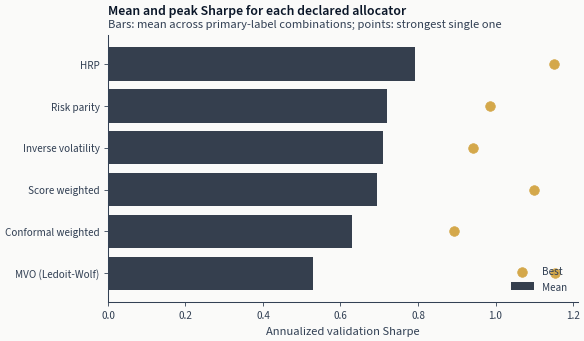

In [12]:
plot_alloc = alloc_comparison.sort("avg_sharpe")
fig, ax = plt.subplots(figsize=FIGSIZE["single"], constrained_layout=True)
y = range(len(plot_alloc))
_ALLOCATOR_NAMES = {
    "inverse_vol": "Inverse volatility",
    "mvo_ledoit_wolf": "MVO (Ledoit-Wolf)",
    "hrp": "HRP",
}


def allocator_label(method: str) -> str:
    """Chart label for an allocator declared in `setup.yaml`."""
    return _ALLOCATOR_NAMES.get(method, method.replace("_", " ").capitalize())


labels = [allocator_label(name) for name in plot_alloc["allocator"].to_list()]
ax.barh(y, plot_alloc["avg_sharpe"], color=COLORS["blue"], alpha=0.82, label="Mean")
ax.scatter(plot_alloc["best_sharpe"], y, color=COLORS["amber"], s=48, zorder=3, label="Best")
ax.set_yticks(list(y), labels)
ax.set_xlabel("Annualized validation Sharpe")
ax.legend(frameon=False, loc="lower right")
add_message_title(
    ax,
    "Mean and peak Sharpe for each declared allocator",
    "Bars: mean across primary-label combinations; points: strongest single one",
)
show_with_alt(
    fig,
    "Horizontal bars of mean validation Sharpe for each allocator, ordered by that mean, with a "
    "separate marker for the allocator's best single configuration.",
)

## 4. Inspect the leading allocation

The table keeps the highest-Sharpe rows visible, and the figure after it shows whether that
result depends on one concentration choice. **Read the two together.** A row that leads at one
`top_k` and disappears at the next is a concentration artefact rather than an allocator that
suits this signal, and the sweep runs every level precisely so that is visible rather than
assumed.

In [13]:
top_rows = explorer.best(
    stage="allocation",
    top_n=10,
    label=ALLOCATION_LABEL,
    prediction_hashes=selected_hashes,
)
winner = explorer.inspect(top_rows["backtest_hash"][0])
winner_strategy = winner.spec["strategy"]
winner_allocator = winner_strategy["allocation"]["method"]
winner_top_k = winner_strategy["signal"]["top_k"]
baseline_sharpe = top_preds.filter(pl.col("prediction_hash") == winner.prediction_hash)["sharpe"][0]
allocation_delta = winner.metrics["sharpe"] - baseline_sharpe

print(
    f"Selected allocation: {winner.source}; allocator={winner_allocator}; "
    f"top_k={winner_top_k}; validation Sharpe={winner.metrics['sharpe']:.3f}"
)
print(f"Equal-weight baseline={baseline_sharpe:.3f}; allocation delta={allocation_delta:+.3f}")
top_rows.select("source", "prediction_hash", "sharpe", "cagr", "max_drawdown")

Selected allocation: gbm/default_mae; allocator=mvo_ledoit_wolf; top_k=5; validation Sharpe=1.154
Equal-weight baseline=0.804; allocation delta=+0.350


source,prediction_hash,sharpe,cagr,max_drawdown
str,str,f64,f64,f64
"""gbm/default_mae""","""88aae998c166""",1.15407,0.562623,-0.550489
"""gbm/leaves_7_mae""","""6059d7717087""",1.149648,0.398129,-0.402896
"""latent_factors/sae""","""e9feadf20800""",1.136212,0.609009,-0.459456
"""gbm/leaves_15_huber""","""4aa944641910""",1.102202,0.33759,-0.302188
"""latent_factors/sae""","""e9feadf20800""",1.099791,0.562894,-0.467053
"""latent_factors/sae""","""e9feadf20800""",1.099193,0.361453,-0.306232
"""latent_factors/sae""","""e9feadf20800""",1.087492,0.54159,-0.459195
"""gbm/leaves_7_huber""","""a959d60aaff3""",1.018549,0.376775,-0.43217
"""gbm/leaves_7_huber""","""a959d60aaff3""",1.004266,0.300806,-0.363348


The point estimate is conditional on selecting this row from the full allocation sweep. An
ordinary interval for this one return path would omit that search, so it is not reported as
uncertainty about the selected allocation.

The curve below asks whether the allocation result depends on how many names are
held. A Sharpe that falls as the basket widens is what dilution of the
cross-sectional ranking looks like; one that is flat says the allocator, not the
concentration, is doing the work.

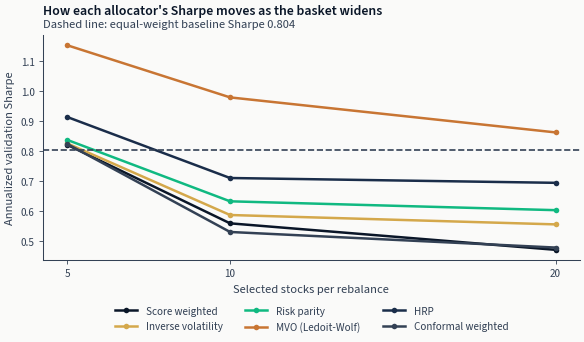

In [14]:
winner_curve = explorer.concentration_curve(winner.prediction_hash).filter(
    pl.col("allocator").is_in(allocation_methods)
)
palette = [
    COLORS["blue"],
    COLORS["amber"],
    COLORS["positive"],
    COLORS["copper"],
    COLORS["slate"],
    COLORS["neutral"],
][: len(allocation_methods)]

fig, ax = plt.subplots(figsize=FIGSIZE["single"], constrained_layout=True)
for color, method in zip(palette, allocation_methods, strict=True):
    curve = winner_curve.filter(pl.col("allocator") == method).sort("top_k")
    ax.plot(
        curve["top_k"],
        curve["sharpe"],
        marker="o",
        linewidth=1.8,
        color=color,
        label=allocator_label(method),
    )
ax.axhline(baseline_sharpe, color=COLORS["neutral"], linestyle="--", linewidth=1.2)
ax.set_xticks(TOP_K_VALUES)
ax.set_xlabel("Selected stocks per rebalance")
ax.set_ylabel("Annualized validation Sharpe")
ax.legend(
    frameon=False,
    ncol=3,
    fontsize=8,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.16),
)
add_message_title(
    ax,
    "How each allocator's Sharpe moves as the basket widens",
    f"Dashed line: equal-weight baseline Sharpe {baseline_sharpe:.3f}",
)
show_with_alt(
    fig,
    "One line per allocator of annualized validation Sharpe against the number of stocks selected "
    "per rebalance, with a dashed horizontal line at the equal-weight baseline.",
)

## Key takeaways

1. **Equal weight is the baseline, not a competitor.** It is the signal stage's own weighting,
   so it is excluded from the allocator menu and the notebook raises if it reappears there.
   Every Sharpe here is read against it rather than ranked alongside it.

2. **An allocator is judged across concentration levels, not at one.** The method averages and
   the per-`top_k` figure answer different questions: which allocator suits this signal on
   average, and whether its leading row persists when the number of names held changes.

3. **The gain from allocation is measured against that lineage's own baseline.** The
   difference between a lineage's equal-weight Sharpe and its highest allocated Sharpe is
   what allocation contributed. That comparison holds the predictions fixed, which is what
   isolates the allocator's effect from the signal's.

4. **The declared allocators read three different things.** Score weighting reads the
   point prediction, `conformal_weighted` reads the width of its interval, and inverse
   volatility, risk parity, MVO and HRP weight by a moment of returns. Where the conformal
   intervals under-cover out of time - which `13_model_analysis` measures - only the
   interval-width allocator inherits that miscalibration, so read its result beside that
   coverage rather than on its own.

5. **These are selection-stage results on a current-constituent universe**, so they carry
   survivorship bias and establish no out-of-sample edge. The holdout is untouched here.

**Next:** [`16_risk_management`](16_risk_management.ipynb) applies friction to the leading validation lineage. See
Chapter 18 for the transaction-cost framework.